# ⛰️ บทที่ 11 — Beam Blockage Analysis ด้วย DEM
### หลักสูตรแลปเรดาร์ตรวจอากาศด้วย Py-ART และ wradlib

**ระดับ:** ขั้นสูง  |  **ต้องมีก่อน:** รันบทที่ 00 แล้ว (ใช้ DEM `wrl_dem_phk1.tif`; ต่อยอดเรขาคณิตลำบีมจากบท 10)

**วัตถุประสงค์การเรียนรู้**
- เข้าใจ **การบดบังลำบีมบางส่วน (PBB)** และ **การบดบังสะสม (CBB)**
- คำนวณ PBB/CBB รอบสถานีพิษณุโลกจาก DEM
- ทำ **แผนที่การบดบังเชิงพื้นที่** และ **โปรไฟล์การบดบังตาม azimuth**
- ประเมิน **% พื้นที่ที่ถูกบดบัง** และส่งออกเป็น GeoTIFF

---


## 🧠 หลักการเบื้องต้น

เมื่อภูมิประเทศ (ภูเขา) สูงพอที่จะกีดขวางลำบีม พลังงานส่วนหนึ่งถูกบัง ทำให้ค่าที่วัดได้ต่ำกว่าจริง (**ประเมินฝนต่ำเกินไป** ในทิศนั้น)

- **PBB (Partial Beam Blocking)** — สัดส่วนพื้นที่หน้าตัดลำบีมที่ถูกบังที่ตำแหน่งหนึ่ง (0 = ไม่บัง, 1 = บังหมด) คำนวณจากความสูงภูมิประเทศ (Th) เทียบความสูงศูนย์กลางลำบีม (Bh) และรัศมีครึ่งกำลังของบีม (a) ตามสูตรของ Bech et al. (2003)
- **CBB (Cumulative Beam Blocking)** — การบดบัง**สะสม**ตามแนวรัศมี (เมื่อถูกบังแล้วจะบังต่อเนื่องไปด้านหลัง) = ค่าสูงสุดของ PBB ที่สะสมมาตามระยะ

ผลของการบดบังสำคัญต่อ QPE (บท 08) และการเลือกกลยุทธ์การกวาด/ตำแหน่งสถานี

> ใช้ฟังก์ชันของ `wradlib.qual` (`beam_block_frac`, `cum_beam_block_frac`) ถ้ามี ไม่งั้นใช้สูตรที่คำนวณเองในบทนี้ (ผลเท่ากัน)


## ⚙️ ส่วนหัวมาตรฐาน (ติดตั้งไลบรารี + เชื่อม Drive + ฟอนต์ไทย)


In [ ]:
%pip install -q arm_pyart wradlib rasterio geopandas pyproj scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.4/14.4 MB 90.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 119.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 70.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 125.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.5/307.5 kB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.9/203.9 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 72.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.8/157.8 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.5/89.5 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.3/47.3 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 109.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not curre

In [ ]:
import os, sys, shutil
import numpy as np
import matplotlib.pyplot as plt
import pyart, rasterio, geopandas as gpd
from pyproj import Geod, Transformer
import warnings; warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')
ROOT = '/content/drive/MyDrive/tmd_radar_course'
sys.path.append(os.path.join(ROOT, '9config'))
import course_paths as P
assert os.path.exists(P.DEM), "⚠️ ไม่พบไฟล์ DEM — กรุณารัน Notebook 00 ก่อน"
OUT = P.results_dir('lesson11')
print("พร้อมแล้ว ✅  ผลลัพธ์บันทึกที่:", OUT)


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly supported
## by the U.S. Department of Energy Office of Science as part of
## the Atmospheric Radiation Measurement (ARM) User Facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119

Mounted at /content/drive
พร้อมแล้ว ✅  ผลลัพธ์บันทึกที่: /content/drive/MyDrive/tmd_radar_course/1results/lesson11


### 🔤 ติดตั้งฟอนต์ไทยสำหรับกราฟ (จำเป็น — มิฉะนั้นข้อความไทยจะแสดงเป็นกล่อง □□□)

ดาวน์โหลดฟอนต์ **Sarabun** (ฟอนต์ราชการไทย เหมาะงานตีพิมพ์) มาลงทะเบียนกับ matplotlib พร้อมตั้งสไตล์กราฟระดับตีพิมพ์ — รันเซลล์นี้ก่อนพลอตทุกครั้ง

In [ ]:
# ── ติดตั้ง & ตั้งค่าฟอนต์ไทยให้ matplotlib (ต้องรันก่อนพลอตกราฟที่มีข้อความไทย) ──
import os, glob, subprocess, urllib.request
import matplotlib as mpl, matplotlib.pyplot as plt, matplotlib.font_manager as fm

def setup_thai_font(verbose=True):
    d = '/usr/share/fonts/truetype/sarabun'; os.makedirs(d, exist_ok=True)
    # 1) Sarabun จาก Google Fonts (ฟอนต์ราชการไทย)
    if not glob.glob(d + '/*.ttf'):
        base = 'https://github.com/google/fonts/raw/main/ofl/sarabun/'
        for fn in ('Sarabun-Regular.ttf', 'Sarabun-Bold.ttf'):
            try: urllib.request.urlretrieve(base + fn, os.path.join(d, fn))
            except Exception: pass
    # 2) สำรอง: ฟอนต์ไทย TLWG ผ่าน apt (มีใน Colab เสมอ)
    if not glob.glob(d + '/*.ttf') and not glob.glob('/usr/share/fonts/truetype/tlwg/*.ttf'):
        subprocess.run(['apt-get', '-qq', '-y', 'install', 'fonts-thai-tlwg'], capture_output=True)
    # ลงทะเบียนฟอนต์ที่ติดตั้ง
    for fp in glob.glob(d + '/*.ttf') + glob.glob('/usr/share/fonts/truetype/tlwg/*.ttf'):
        try: fm.fontManager.addfont(fp)
        except Exception: pass
    avail = {f.name for f in fm.fontManager.ttflist}
    chosen = next((n for n in ('Sarabun','Loma','Garuda','Norasi') if n in avail), None)
    if chosen: mpl.rcParams['font.family'] = chosen
    mpl.rcParams['axes.unicode_minus'] = False
    if verbose:
        print('ฟอนต์ไทยที่ใช้:', chosen or 'ไม่พบ — ลองรันเซลล์นี้อีกครั้งหลังติดตั้ง')
    return chosen

setup_thai_font()
# สไตล์กราฟระดับตีพิมพ์ (ฟอนต์ใหญ่ อ่านง่าย)
plt.rcParams.update({'figure.dpi':120, 'savefig.dpi':300, 'font.size':13,
    'axes.titlesize':16, 'axes.labelsize':14, 'xtick.labelsize':12,
    'ytick.labelsize':12, 'legend.fontsize':13, 'axes.unicode_minus':False})

ฟอนต์ไทยที่ใช้: Sarabun


## 1️⃣ ตำแหน่งสถานี + แผนที่ DEM รอบสถานี


สถานีพิษณุโลก: lon=100.2180, lat=16.7754, ความสูง=72 m
มุมยกต่ำสุด = 0.48°


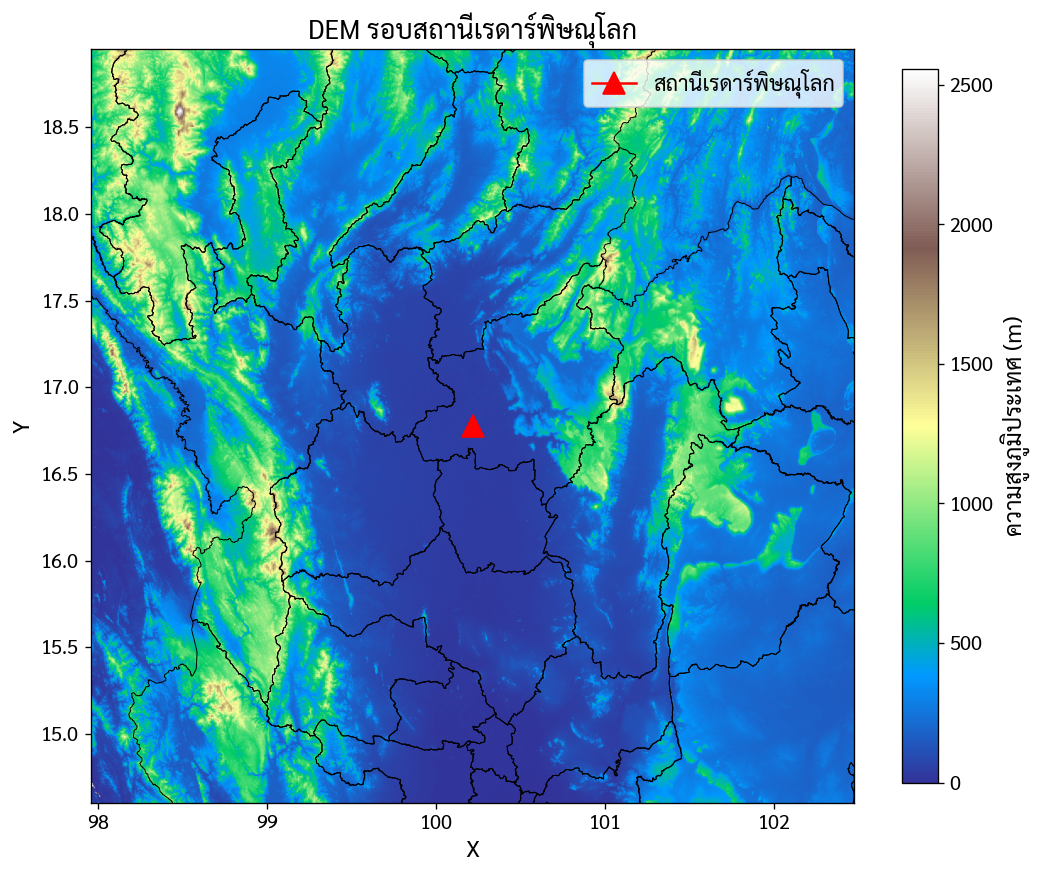

In [ ]:
radar = pyart.io.read(P.RADAR_1000)
lon0 = float(radar.longitude['data'][0])
lat0 = float(radar.latitude['data'][0])
alt0 = float(radar.altitude['data'][0])
elevs = np.array([float(a) for a in radar.fixed_angle['data']])
print(f"สถานีพิษณุโลก: lon={lon0:.4f}, lat={lat0:.4f}, ความสูง={alt0:.0f} m")
print(f"มุมยกต่ำสุด = {elevs.min():.2f}°")

# แผนที่ DEM
prov = gpd.read_file(P.PROVINCE_SHP)
if prov.crs is None: prov = prov.set_crs('EPSG:4326')

with rasterio.open(P.DEM) as ds:
    dem = ds.read(1).astype(float)
    if ds.nodata is not None: dem[dem == ds.nodata] = np.nan
    b = ds.bounds; dem_crs = ds.crs if ds.crs else 'EPSG:4326'
    extent = [b.left, b.right, b.bottom, b.top]

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(dem, extent=extent, origin='upper', cmap='terrain')
prov.to_crs(dem_crs).boundary.plot(ax=ax, edgecolor='black', linewidth=0.6)
tr0 = Transformer.from_crs('EPSG:4326', dem_crs, always_xy=True)
sx, sy = tr0.transform(lon0, lat0)
ax.plot(sx, sy, marker='^', color='red', markersize=13, label='สถานีเรดาร์พิษณุโลก')
ax.set_xlim(extent[0], extent[1]); ax.set_ylim(extent[2], extent[3])
ax.legend(); cb = plt.colorbar(im, ax=ax, shrink=0.8); cb.set_label('ความสูงภูมิประเทศ (m)')
ax.set_title('DEM รอบสถานีเรดาร์พิษณุโลก'); ax.set_xlabel('X'); ax.set_ylabel('Y')
plt.tight_layout(); plt.show()

## 2️⃣ สร้างกริดโพลาร์และสุ่มความสูงภูมิประเทศจาก DEM

สร้างตำแหน่ง (azimuth × ระยะ) รอบสถานี แล้วสุ่มค่า DEM ที่แต่ละจุด


In [ ]:
geod = Geod(ellps='WGS84')
azimuths  = np.arange(0, 360, 1.0)               # 360 ทิศ (องศา)
range_res = 1000.0
ranges    = np.arange(range_res/2, 240000, range_res)   # ศูนย์กลาง gate (m)
nrays, nbins = len(azimuths), len(ranges)

AZ, R = np.meshgrid(azimuths, ranges, indexing='ij')     # (nrays, nbins)
lon2d, lat2d, _ = geod.fwd(np.full(AZ.size, lon0), np.full(AZ.size, lat0),
                           AZ.ravel(), R.ravel())
lon2d = lon2d.reshape(AZ.shape); lat2d = lat2d.reshape(AZ.shape)

with rasterio.open(P.DEM) as ds:
    tr = Transformer.from_crs('EPSG:4326', ds.crs if ds.crs else 'EPSG:4326', always_xy=True)
    xs, ys = tr.transform(lon2d.ravel(), lat2d.ravel())
    terr = np.array([v[0] for v in ds.sample(np.c_[xs, ys])], dtype=float).reshape(AZ.shape)
    if ds.nodata is not None: terr[terr == ds.nodata] = np.nan

terr[terr < -1000] = np.nan
terr = np.nan_to_num(terr, nan=0.0)   # นอกขอบ DEM ถือเป็นระดับน้ำทะเล
print("สุ่มความสูงภูมิประเทศแบบโพลาร์แล้ว:", terr.shape, "| ภูเขาสูงสุดในรัศมี:", round(np.nanmax(terr)), "m")

สุ่มความสูงภูมิประเทศแบบโพลาร์แล้ว: (360, 240) | ภูเขาสูงสุดในรัศมี: 1974 m


## 3️⃣ คำนวณ PBB และ CBB (มุมยกต่ำสุด)


In [ ]:
A_EARTH = 6371000.0; KE = 4.0/3.0; BEAMWIDTH = 1.0

def beam_height(r, elev_deg, h0):
    th = np.radians(elev_deg)
    return np.sqrt(r**2 + (KE*A_EARTH)**2 + 2*r*KE*A_EARTH*np.sin(th)) - KE*A_EARTH + h0

def half_power_radius(r, bw_deg):
    return r * np.radians(bw_deg) / 2.0

def beam_block_frac(Th, Bh, a):
    "PBB ตามสูตร Bech et al. (2003) — เวกเตอร์ไรซ์"
    y = Th - Bh
    out = np.zeros_like(y, dtype=float)
    out[y >= a] = 1.0
    m = (y > -a) & (y < a)
    ym, am = y[m], a[m]
    out[m] = (ym*np.sqrt(am**2 - ym**2) + am**2*np.arcsin(ym/am) + np.pi*am**2/2.0) / (np.pi*am**2)
    return out

elev = float(elevs.min())
BH = beam_height(ranges, elev, alt0)             # (nbins,)
a_rad = half_power_radius(ranges, BEAMWIDTH)     # (nbins,)
BH2 = np.broadcast_to(BH, terr.shape)
a2  = np.broadcast_to(a_rad, terr.shape)

# ใช้ wradlib ถ้ามี ไม่งั้นใช้สูตรข้างบน (ผลเท่ากัน)
try:
    import wradlib as wrl
    PBB = wrl.qual.beam_block_frac(terr, BH2, a2)
    PBB = np.ma.masked_invalid(PBB).filled(0.0)
    CBB = np.ma.filled(wrl.qual.cum_beam_block_frac(np.ma.masked_invalid(PBB)), 0.0)
    print("ใช้ wradlib.qual ✅")
except Exception as e:
    PBB = beam_block_frac(terr, BH2, a2)
    CBB = np.maximum.accumulate(PBB, axis=1)       # สะสมตามระยะ
    print("ใช้สูตรคำนวณเอง (Bech 2003):", repr(e))

print(f"มุมยก {elev:.2f}° | CBB สูงสุด = {CBB.max():.2f}")

ใช้ wradlib.qual ✅
มุมยก 0.48° | CBB สูงสุด = 0.87


## 4️⃣ แผนที่การบดบังสะสม (CBB) เชิงพื้นที่


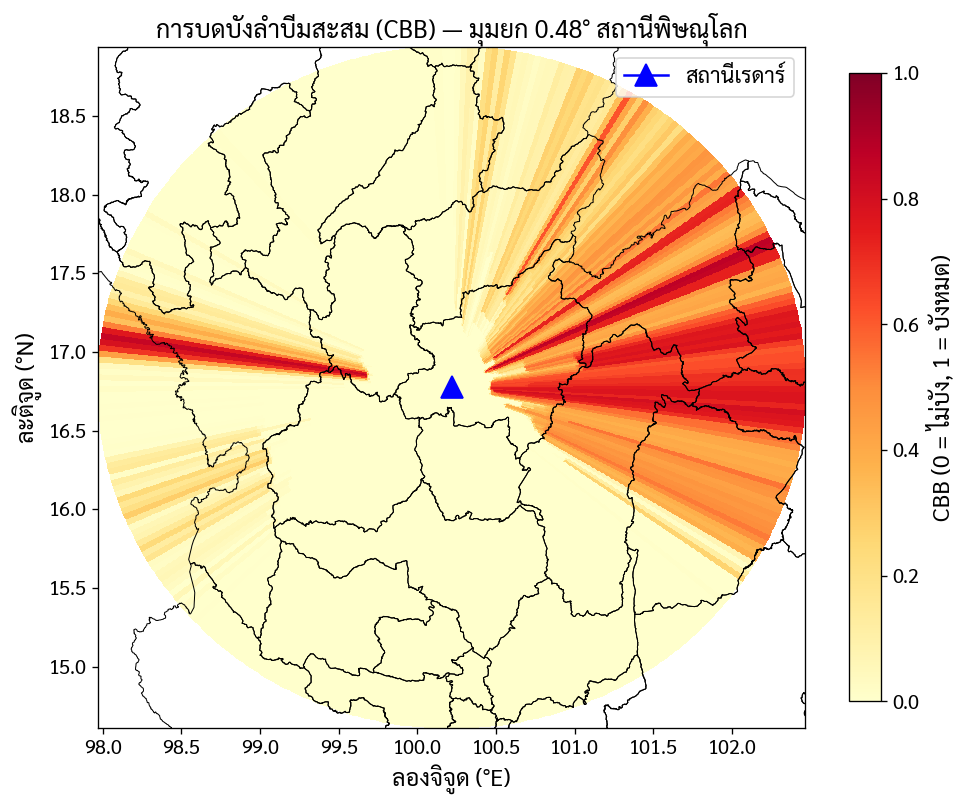

In [ ]:
fig, ax = plt.subplots(figsize=(9.5, 8.5))
pm = ax.pcolormesh(lon2d, lat2d, CBB, cmap='YlOrRd', vmin=0, vmax=1, shading='auto')
prov.boundary.plot(ax=ax, edgecolor='black', linewidth=0.6)
ax.plot(lon0, lat0, marker='^', color='blue', markersize=13, label='สถานีเรดาร์')
ax.set_xlim(lon2d.min(), lon2d.max()); ax.set_ylim(lat2d.min(), lat2d.max())
ax.set_aspect('equal'); ax.legend()
ax.set_xlabel('ลองจิจูด (°E)'); ax.set_ylabel('ละติจูด (°N)')
ax.set_title(f'การบดบังลำบีมสะสม (CBB) — มุมยก {elev:.2f}° สถานีพิษณุโลก', fontsize=15)
cb = plt.colorbar(pm, ax=ax, shrink=0.8); cb.set_label('CBB (0 = ไม่บัง, 1 = บังหมด)')
fig.savefig(os.path.join(OUT, 'cbb_map.png'), dpi=300, bbox_inches='tight')
plt.show()

## 5️⃣ โปรไฟล์การบดบังตาม azimuth + % พื้นที่ที่ถูกบัง


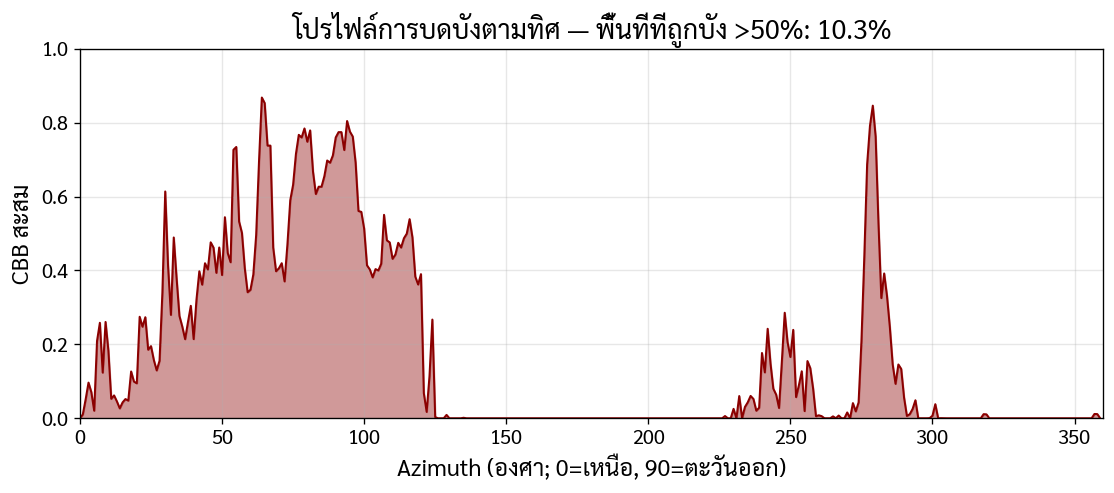

ทิศที่ถูกบดบังมากที่สุด (azimuth°): [ 64.  65. 279.  94. 278.]
สัดส่วนพื้นที่ตรวจวัดที่ CBB > 0.5 ≈ 10.3%


In [ ]:
cbb_far = CBB[:, -1]     # การบดบังสะสมที่ระยะไกลสุด (รวมของแต่ละทิศ)
pct_blocked = float((CBB > 0.5).mean()) * 100

fig, ax = plt.subplots(figsize=(11, 4))
ax.fill_between(azimuths, cbb_far, color='darkred', alpha=0.4)
ax.plot(azimuths, cbb_far, color='darkred', lw=1.2)
ax.set_xlabel('Azimuth (องศา; 0=เหนือ, 90=ตะวันออก)'); ax.set_ylabel('CBB สะสม')
ax.set_title(f'โปรไฟล์การบดบังตามทิศ — พื้นที่ที่ถูกบัง >50%: {pct_blocked:.1f}%')
ax.set_xlim(0, 360); ax.set_ylim(0, 1); ax.grid(alpha=0.3)
fig.savefig(os.path.join(OUT, 'cbb_azimuth_profile.png'), dpi=300, bbox_inches='tight')
plt.show()

worst = azimuths[np.argsort(cbb_far)[-5:]][::-1]
print("ทิศที่ถูกบดบังมากที่สุด (azimuth°):", np.round(worst,0))
print(f"สัดส่วนพื้นที่ตรวจวัดที่ CBB > 0.5 ≈ {pct_blocked:.1f}%")

## 6️⃣ ส่งออก CBB เป็น GeoTIFF (สำหรับ QGIS)

แปลงค่า CBB แบบโพลาร์ให้เป็นกริด lat/lon สม่ำเสมอ แล้วเขียนเป็น GeoTIFF (เขียนลงเครื่องก่อนแล้วคัดลอกขึ้น Drive)


In [ ]:
try:
    from scipy.interpolate import griddata
    n = 481
    gx = np.linspace(lon2d.min(), lon2d.max(), n)
    gy = np.linspace(lat2d.min(), lat2d.max(), n)
    GX, GY = np.meshgrid(gx, gy)
    grid_cbb = griddata(np.c_[lon2d.ravel(), lat2d.ravel()], CBB.ravel(),
                        (GX, GY), method='linear')
    grid_cbb = np.nan_to_num(grid_cbb, nan=0.0).astype('float32')

    local_tif = '/content/cbb_phs.tif'
    tif_path  = os.path.join(OUT, 'cbb_phs.tif')
    transform = rasterio.transform.from_bounds(gx.min(), gy.min(), gx.max(), gy.max(), n, n)
    with rasterio.open(local_tif, 'w', driver='GTiff', height=n, width=n, count=1,
                       dtype='float32', crs='EPSG:4326', transform=transform) as dst:
        dst.write(np.flipud(grid_cbb), 1)     # แถวแรกของ raster = ละติจูดสูงสุด
    shutil.copy(local_tif, tif_path)
    print("ส่งออก GeoTIFF แล้ว:", tif_path)
    with rasterio.open(tif_path) as ds:
        print("  ขนาด:", ds.width, "x", ds.height, "| CRS:", ds.crs)
except Exception as e:
    print("ข้ามการส่งออก GeoTIFF:", repr(e))

ส่งออก GeoTIFF แล้ว: /content/drive/MyDrive/tmd_radar_course/1results/lesson11/cbb_phs.tif
  ขนาด: 481 x 481 | CRS: EPSG:4326


## 📝 แบบฝึกหัด

1. เปลี่ยน `elev` เป็นมุมยกที่สูงขึ้น (เช่น ค่าที่สองใน `elevs`) แล้วคำนวณ CBB ใหม่ — การบดบังลดลงมากน้อยเพียงใด?
2. เทียบ **โปรไฟล์การบดบัง** ของมุมยกต่ำสุด vs มุมยกสูงขึ้น บนกราฟเดียวกัน
3. (อภิปราย) ถ้าย้ายสถานีขึ้นที่สูงหรือเลี่ยงภูเขา (เช่นกรณีศึกษาการย้ายสถานี) การบดบังจะดีขึ้นในทิศใด?


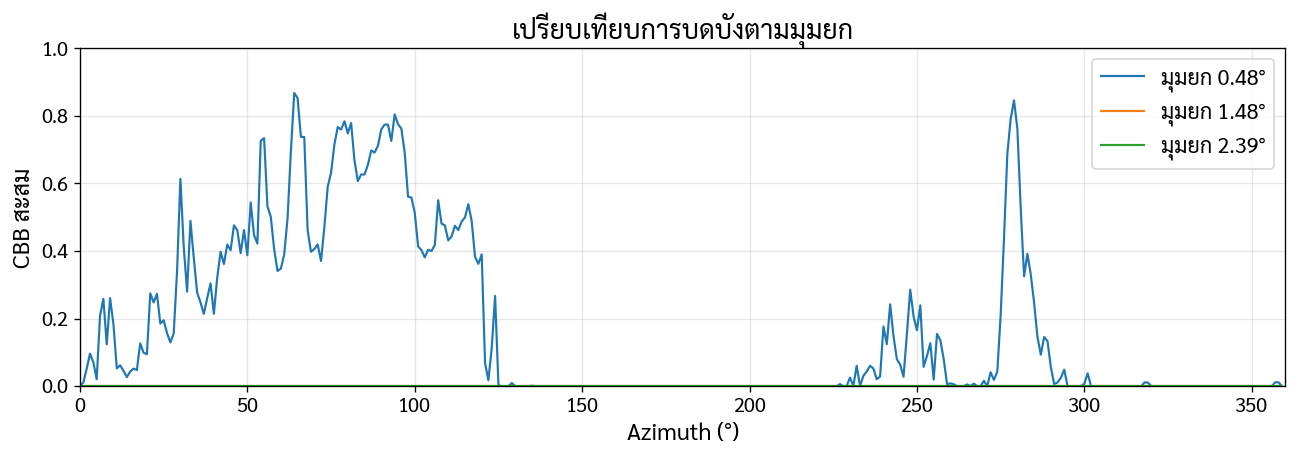

In [ ]:
# แบบฝึกหัดข้อ 1–2 (โครงเริ่มต้น): เทียบ CBB หลายมุมยก
def compute_cbb(elev_deg):
    BH = np.broadcast_to(beam_height(ranges, elev_deg, alt0), terr.shape)
    a2 = np.broadcast_to(half_power_radius(ranges, BEAMWIDTH), terr.shape)
    pbb = beam_block_frac(terr, BH, a2)
    return np.maximum.accumulate(pbb, axis=1)

fig, ax = plt.subplots(figsize=(11, 4))
for e in elevs[:3]:
    cbb_e = compute_cbb(float(e))
    ax.plot(azimuths, cbb_e[:, -1], lw=1.3, label=f'มุมยก {e:.2f}°')
ax.set_xlabel('Azimuth (°)'); ax.set_ylabel('CBB สะสม'); ax.set_xlim(0, 360); ax.set_ylim(0, 1)
ax.legend(); ax.grid(alpha=0.3); ax.set_title('เปรียบเทียบการบดบังตามมุมยก')
plt.tight_layout(); plt.show()
# TODO (นิสิต): ทำข้อ 3 (อภิปราย) ต่อ

---
## 🎯 สรุป

- **PBB** = การบดบังบางส่วนที่จุดหนึ่ง, **CBB** = การบดบังสะสมตามแนวรัศมี
- ทิศที่มีภูเขาสูง (จาก DEM) จะมี CBB สูง → ตรวจฝนได้ต่ำกว่าจริงในทิศนั้น
- มุมยกที่สูงขึ้นช่วยลดการบดบัง แต่แลกกับการตรวจไม่ถึงฝนระดับต่ำ
- แผนที่/โปรไฟล์ CBB และ GeoTIFF ใช้ประกอบการตัดสินใจเชิงคุณภาพข้อมูลและการวางสถานี

**บทถัดไปที่เกี่ยวข้อง:** บท 12 (zonal statistics) — นำคุณภาพ/ฝนที่ได้ไปสรุปรายลุ่มน้ำ โดยระวังพื้นที่ที่ถูกบดบัง
